# Getting the files

In [ ]:
# !pip install gdown
import gdown
destination = '/content/pdf_json.zip' # store the destination file here
# gdown.download('https://drive.google.com/uc?id=1PVA5IR4bAn7RulAeuSgxRBNMtmRGXaUm', destination, quiet=True) # this is the original link to dataset but it became inaccessible before the submission due to some gdown limit on users so I had to manually download the file from that link and upload to my gdrive and use gdown on that
gdown.download('https://drive.google.com/uc?id=15qcBU4HVSd-Vhm0kaTZt-VsBfbyK0FSn', destination, quiet=True) # this is link of the dataset from my gdrive account but in case this is not accessible please comment this line and try the line above

'/content/pdf_json.zip'

In [ ]:
# !rm -rf pdf_json prep_data.txt texts_data.txt # remove the files and folders from previous computations if necessary

In [ ]:
!unzip -q "/content/pdf_json.zip" # unzipping the file

# Task 1

In [ ]:
import json
def json2text(filename): # json to text converter
    file = open(filename)
    paper_content = json.load(file)
    body_text = ""
    abstract = ""
    title = ""
    # Get the paper_id
    paper_id = paper_content['paper_id']
    # Get the title
    if 'title' in paper_content:
        title = paper_content['title']
    # Get the abstract
    if 'abstract' in paper_content:
        for abs in paper_content['abstract']:
            abstract += abs['text']
    # Get the body text
    if 'body_text' in paper_content:
        for bt in paper_content['body_text']:
            body_text += bt['text']
    return (f'{title} {abstract} {body_text}').lower()

In [ ]:
import os
import multiprocessing as mp
from multiprocessing import Pool

def write_file(filename): # writing the json files into a single text file using multiprocessing
    with open(filename, 'r') as fd:
        return json2text(filename) + " " # we are storing the texts from the json files

def par_write(files):
    '''Read a chunk of files and let the cores of your machine do the job of format conversion in parallel'''
    # Parameter: files - list of files from a folder
    cpu_count = os.cpu_count()
    p = Pool(processes=cpu_count)
    texts_data_list = p.map(write_file, files, chunksize=16)
    p.close()
    p.join()
    data = "\n".join(texts_data_list)
    return data


In [ ]:
folder_path = '/content/pdf_json' # input folder path
files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.json')] # storing the list of paths from the input folder
texts_data = par_write(files) # this is storing all the text files from the json files separated by newlines

## Saving the texts in a txt file

In [ ]:
with open('/content/texts_data.txt', 'w', encoding='utf-8') as file:
  file.write(texts_data) # saving the texts in a txt file

In [ ]:
# freeing up the ram
import gc
files = None
texts_data = None
del files
del texts_data
gc.collect()

16579

# Task 2

In [ ]:
import re

input_file_path = "/content/texts_data.txt"
output_file_path = "/content/prep_data.txt" # path to store the preprocessed text file

def preprocess_and_write_line(infile, outfile): # function to do the preprocessing line by line
    while True:
        line = infile.readline()
        if not line:
            break  # end of file reached
        # preprocess the line (case folding and removing numbers)
        preprocessed_line = re.sub(r'[0-9,.":;\'!?(){}[\]<>/\|@#&]', ' ', line.lower())
        # write the preprocessed line to the output file
        outfile.write(preprocessed_line)

# Open input and output files
with open(input_file_path, "r") as infile, open(output_file_path, "w") as outfile:
    preprocess_and_write_line(infile, outfile) # calling the preprocessor function


# Task 3

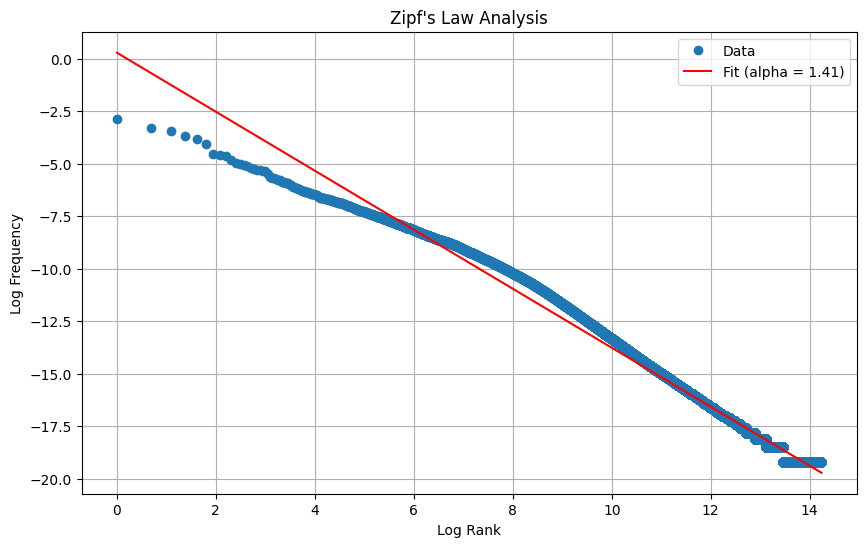

Estimated alpha: 1.41


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from multiprocessing import Pool, cpu_count

def term_frequency(term_counts, total_terms):
    # Convert term counts to term frequency
    term_freq = {}
    for term, freq in term_counts.items():
        term_freq[term] = freq / total_terms
    return term_freq

def zipfs_law_analysis(term_freq):
    # Sort terms by frequency in descending order
    sorted_terms = sorted(term_freq.items(), key=lambda x: x[1], reverse=True)
    ranks = np.arange(1, len(sorted_terms) + 1)
    frequencies = np.array([freq for term, freq in sorted_terms]) # numpy array to store the frequencies

    # Fit Zipf's Law: f(r) = C * r^(-alpha)
    # Find the log of ranks and frequencies
    log_ranks = np.log(ranks)
    log_frequencies = np.log(frequencies)

    # Perform linear regression to find alpha
    A = np.vstack([log_ranks, np.ones(len(log_ranks))]).T
    alpha, _ = np.linalg.lstsq(A, log_frequencies, rcond=None)[0] # doing the linear regression

    # Plotting the graph to check Zipf's Law
    plt.figure(figsize=(10, 6))
    plt.plot(log_ranks, log_frequencies, 'o', label='Data')
    plt.plot(log_ranks, alpha * log_ranks + _ , 'r-', label=f'Fit (alpha = {-alpha:.2f})')
    plt.xlabel('Log Rank')
    plt.ylabel('Log Frequency')
    plt.title('Zipf\'s Law Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()

    return alpha

def count_terms(lines): # counting number of tokens function
    term_counts = Counter() # initializing the counter
    total_terms = 0

    for line in lines:
        tokens = line.split()
        term_counts.update(tokens) # increasing the count with each tokens from the tokens list
        total_terms += len(tokens) # the total number of terms is just the total number of tokens

    return term_counts, total_terms

def file_line_generator(file_path, chunk_size=1000):
    with open(file_path, 'r') as file:
        lines = []
        for line in file:
            lines.append(line)
            if len(lines) >= chunk_size:
                yield lines # yield line by line
                lines = [] # reset the lines when it exceeds the chunk size
        if lines:
            yield lines # yield line by line

def process_file_and_analyze(file_path):
    term_counts = Counter()
    total_terms = 0

    with Pool(cpu_count()) as pool: # using multiprocessing
        for lines_chunk in file_line_generator(file_path):
            results = pool.map(count_terms, [lines_chunk])
            for counts, total in results:
                term_counts.update(counts)
                total_terms += total

    # Find term frequency
    term_freq = term_frequency(term_counts, total_terms)
    # Perform Zipf's Law analysis
    alpha = zipfs_law_analysis(term_freq)

    return alpha

# File path to the text file
file_path = "/content/prep_data.txt"

# Perform analysis
alpha = process_file_and_analyze(file_path)

print(f"Estimated alpha: {-alpha:.2f}")


# Task 4

In [ ]:
import re
from collections import defaultdict
from multiprocessing import Pool, cpu_count

def process_lines(lines):
    token_count = 0
    vocab_set = set()

    for line in lines:
        # Tokenize the line
        tokens = line.split()
        token_count += len(tokens) # updating the token count
        # Update the vocabulary set with new tokens
        vocab_set.update(tokens)

    return token_count, vocab_set

def file_line_generator(file_path, chunk_size=1000): # generating file lines
    with open(file_path, 'r') as file:
        lines = []
        for line in file:
            lines.append(line)
            if len(lines) >= chunk_size: # checking if it is exceeding the chunk_size in which case reset lines list after yielding it
                yield lines # yields the line
                lines = []
        if lines:
            yield lines # yields the line

def process_file(filename):
    total_token_count = 0
    overall_vocab_set = set() # set to store the overall vocabulary

    with Pool(cpu_count()) as pool: # using multiprocessing
        for lines_chunk in file_line_generator(filename):
            results = pool.map(process_lines, [lines_chunk])
            for token_count, vocab_set in results:
                total_token_count += token_count # updating the token counts line by line
                overall_vocab_set.update(vocab_set) # adding the vocabulary

    # Find the vocabulary size
    vocab_size = len(overall_vocab_set)

    return total_token_count, vocab_size

# Path where the the preprocessed data is stored
file_path = '/content/prep_data.txt'

# Process the file and get results
num_tokens, vocab_size = process_file(file_path)

# Print the number of tokens and the vocabulary size
print("Number of tokens: ", num_tokens)
print("Vocabulary size: ", vocab_size)


Number of tokens:  220524429
Vocabulary size:  1523889


# Task 5

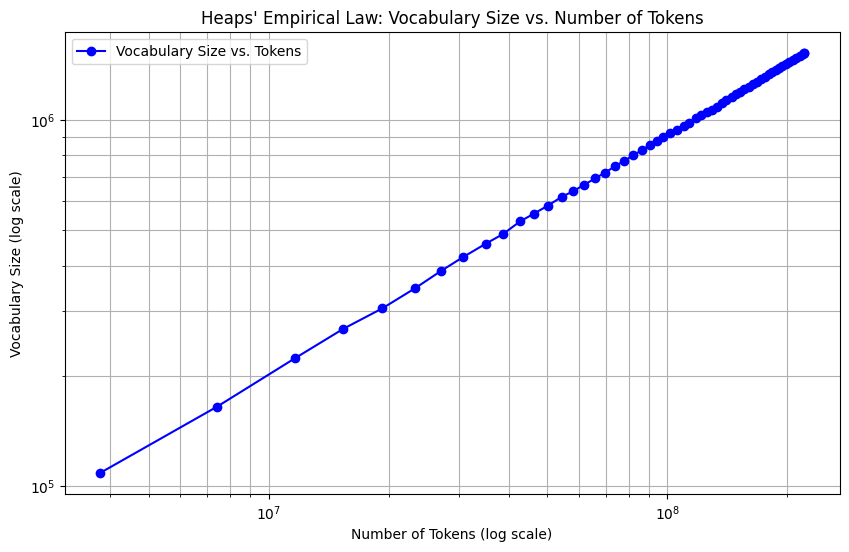

Number of tokens: 3769660, Vocabulary size: 108229
Number of tokens: 7419088, Vocabulary size: 164442
Number of tokens: 11616442, Vocabulary size: 222837
Number of tokens: 15387293, Vocabulary size: 268551
Number of tokens: 19256126, Vocabulary size: 305279
Number of tokens: 23299429, Vocabulary size: 346814
Number of tokens: 27007046, Vocabulary size: 386213
Number of tokens: 30723790, Vocabulary size: 421753
Number of tokens: 34986474, Vocabulary size: 458637
Number of tokens: 38709189, Vocabulary size: 487796
Number of tokens: 42694316, Vocabulary size: 528004
Number of tokens: 46323553, Vocabulary size: 555053
Number of tokens: 50112525, Vocabulary size: 583048
Number of tokens: 54422756, Vocabulary size: 617214
Number of tokens: 58013345, Vocabulary size: 638304
Number of tokens: 61818389, Vocabulary size: 665314
Number of tokens: 65944511, Vocabulary size: 692492
Number of tokens: 69740513, Vocabulary size: 718429
Number of tokens: 74070239, Vocabulary size: 748088
Number of toke

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count

def process_lines(lines): # function to process line by line
    vocab_set = set() # initializing the vocabulary set
    num_tokens = 0

    for line in lines:
        tokens = line.strip().split()  # generating the tokens from each line
        vocab_set.update(tokens) # updating the vocabulary
        num_tokens += len(tokens) # storing the number of tokens in each line

    return num_tokens, vocab_set

def file_line_generator(file_path, chunk_size=1000):
    with open(file_path, 'r') as file:
        lines = []
        for line in file:
            lines.append(line)
            if len(lines) >= chunk_size: # checking chunk size
                yield lines # yielding the lines list to the caller
                lines = [] # if chunk size exceeds then we are resetting the lines list
        if lines:
            yield lines # yielding the lines list

def compute_vocab_size_from_file(file_path, step=10000):
    vocab_sizes = []
    vocab_set = set()
    num_tokens = 0

    with Pool(cpu_count()) as pool: # using multiprocessing
        for lines_chunk in file_line_generator(file_path):
            results = pool.map(process_lines, [lines_chunk])

            for tokens_count, chunk_vocab_set in results:
                num_tokens += tokens_count
                vocab_set.update(chunk_vocab_set)

                # Check if the step interval is reached
                if num_tokens >= len(vocab_sizes) * step:
                    vocab_sizes.append((num_tokens, len(vocab_set)))

    # Append the final state if not already added
    if num_tokens % step != 0:
        vocab_sizes.append((num_tokens, len(vocab_set)))

    return vocab_sizes

# Plotting the analysis of Heap's empirical law
def plot_vocab_vs_tokens(vocab_sizes):
    tokens_counts, vocab_counts = zip(*vocab_sizes)

    plt.figure(figsize=(10, 6))
    plt.plot(tokens_counts, vocab_counts, marker='o', color='blue', label='Vocabulary Size vs. Tokens')
    plt.xscale('log') # setting to log scale for plotting
    plt.yscale('log') # setting to log scale for plotting
    plt.xlabel('Number of Tokens (log scale)')
    plt.ylabel('Vocabulary Size (log scale)')
    plt.title('Heaps\' Empirical Law: Vocabulary Size vs. Number of Tokens')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()

# Specify the path to your text file
file_path = '/content/prep_data.txt'
vocab_sizes = compute_vocab_size_from_file(file_path, step=10000)
plot_vocab_vs_tokens(vocab_sizes)

for num_tokens, vocab_size in vocab_sizes:
    print(f"Number of tokens: {num_tokens}, Vocabulary size: {vocab_size}")
